In [38]:
import numpy as np
import matplotlib.pyplot as plt
!pip install tensorflow

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential

color1,color2,color3,color4,color5 = '#2F4B26','#AA1155','#016FB9','#6CAE75','#330036'


## Data Generation: Sine Curves

Generate **10,000 sine curves** of the form:

$$
x(t) = A \cdot \sin(\omega t + \phi)
$$

where the parameters are drawn from uniform distributions:

- Amplitude: $ A \sim \mathcal{U}[0.5, 1.5] $
- Frequency: $ \omega \sim \mathcal{U}[0.5, 2] $
- Phase: $ \phi \sim \mathcal{U}[0, 2\pi] $

Sample each curve at $N = 100$ equally spaced points over $t \in [0, 4\pi]$.
Your clean_curve array should have shape (10000, 100).
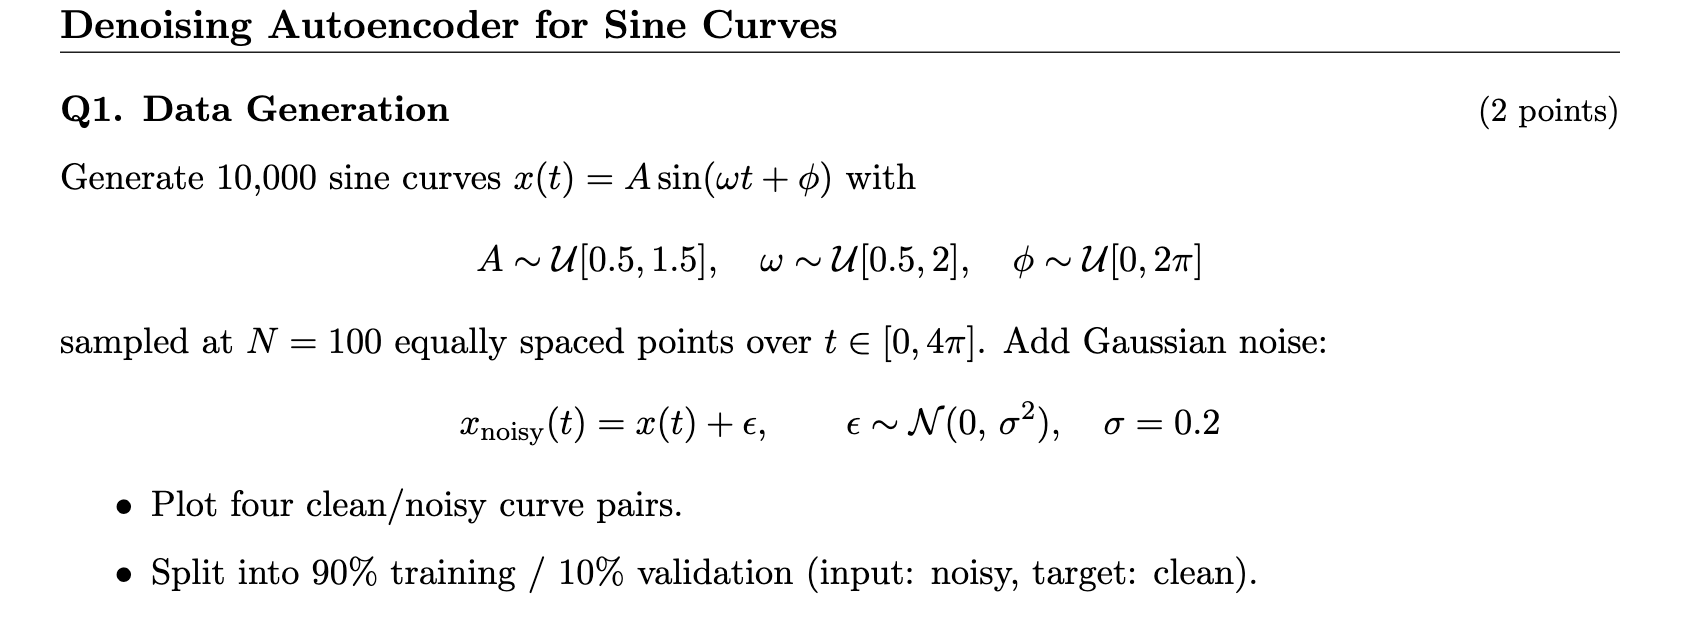

In [25]:
# generate dataset

Q1dataAMP = np.random.uniform(0.5, 1.5, 10000)
Q1dataW = np.random.uniform(0.5, 2, 10000)
Q1dataPhase = np.random.uniform(0, 2*np.pi, 10000)

actualsin = np.zeros((10000, 100))
for i in range(10000):
    for j in range(100):
        actualsin[i][j] = Q1dataAMP[i]*np.sin(Q1dataW[i]*j + Q1dataPhase[i])

#print (actualsin)
print (actualsin.shape)

(10000, 100)


In [ ]:
#for i in range (len(actualsin)):
  #print (actualsin[i][-1])

#plt.plot (actualsin[1])
#print (actualsin[55][99])

## Add Gaussian Noise

$$
x_{\text{noisy}}(t) = x(t) + \epsilon, \qquad \epsilon \sim \mathcal{N}(0, \sigma^2), \quad \sigma = 0.2
$$
Your noisy_curve array should have shape (10000, 100).

In [3]:
noisy_curve=np.zeros((10000,100))

# The noise array should have the same shape as actualsin for element-wise addition
noise = np.random.normal(0, 0.2, actualsin.shape) # Generate noise with shape (10000, 100)
noisy_curve = actualsin + noise

# The original print statement for debugging
#print (len (actualsin[1]))

Plot examples showing the clean and noisy curve.

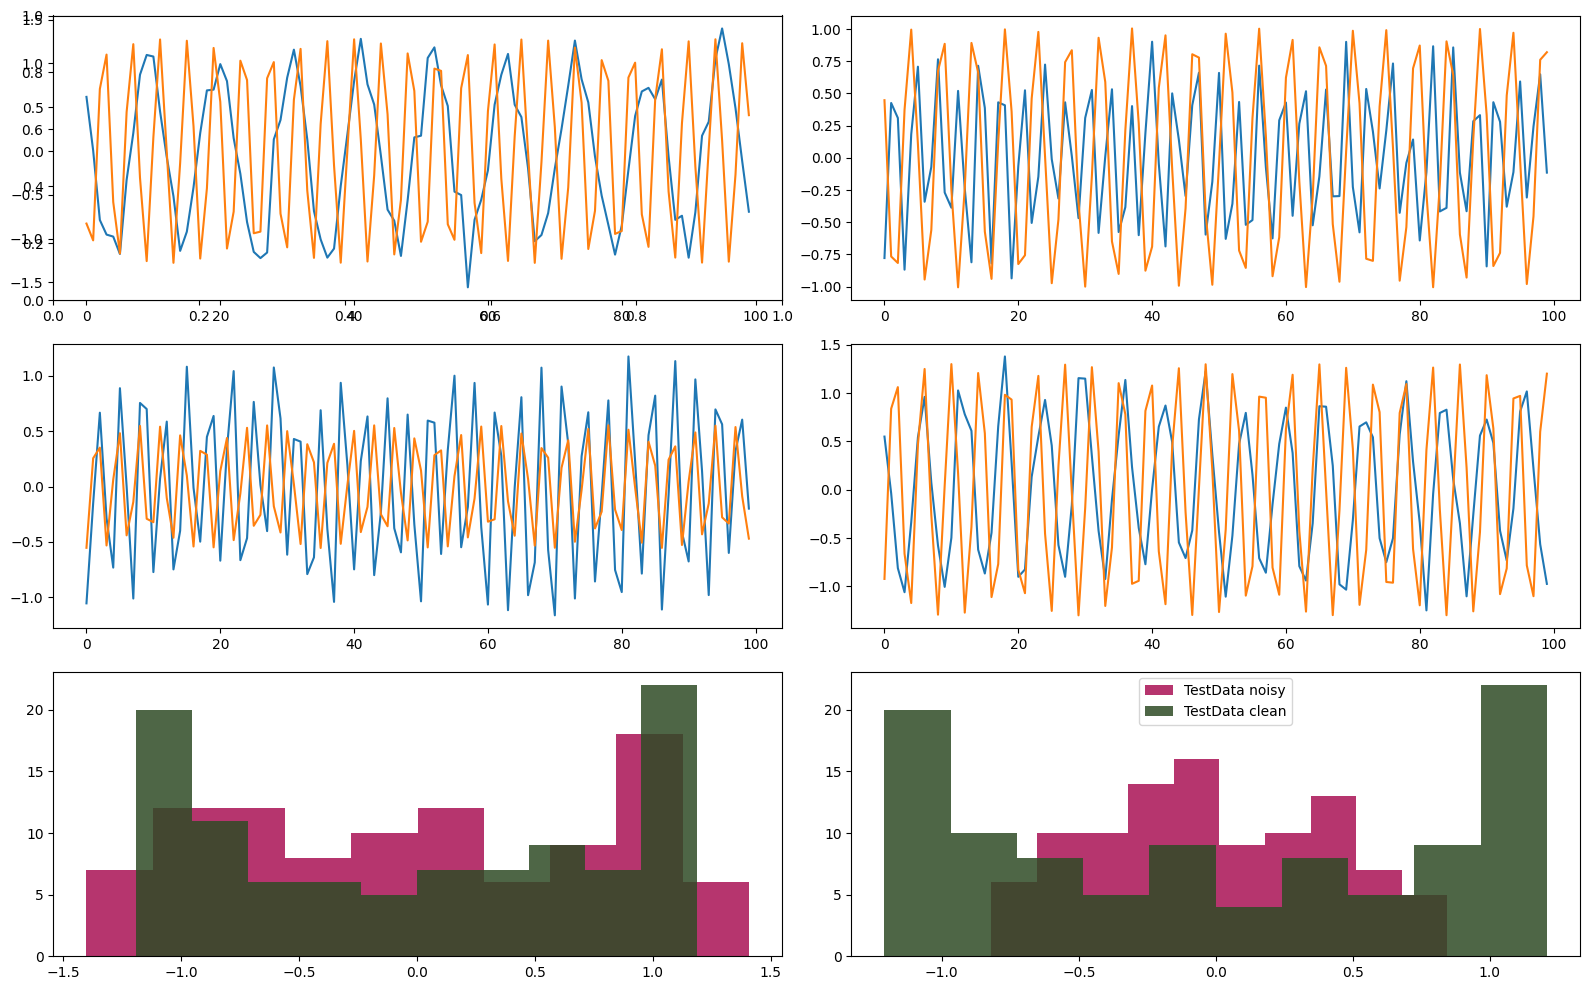

In [43]:
list4 = [1,2,3,4]

fig = plt.figure(figsize=(16,10))

ax=fig.add_subplot(3,2,1)
#ax.plot(noisy_curve[5],label="noisy")
#ax.plot(actualsin[5],label = "clean")
for i in range (len(list4)):
  i=i+1
  ax=fig.add_subplot(3,2,i)
  ax.plot(noisy_curve[i],label="noisy")
  ax.plot(actualsin[i],label = "clean")

# Now split off the training data
num_samples = noisy_curve.shape[0]  # Use the correct variable name
indices = np.random.permutation(num_samples)
split_point = int(0.90 * num_samples)
train_indices = indices[:split_point]
val_indices = indices[split_point:]

# Apply the indices to the correct variable names
x_train = noisy_curve[train_indices]
y_train = actualsin[train_indices]
x_val = noisy_curve[val_indices]
y_val = actualsin[val_indices]

#Plot the clean vs noisy in the training and test sample
ax5 = fig.add_subplot(3,2,5)
ax5.hist(x_train[55],label="TrainData noisy",color=color2,alpha=.85)
ax5.hist(y_train[55],label = "TrainData clean",color=color1,alpha=.85)

ax6 = fig.add_subplot(3,2,6)
ax6.hist(x_val[55],label="TestData noisy",color=color2,alpha=.85)
ax6.hist(y_val[55],label = "TestData clean",color=color1,alpha=.85)


plt.legend()
plt.tight_layout()
plt.show()

## Dataset Split

Split into **90% training / 10% validation**.
- **Input**  (noisy_curve) : X_train -> shape (9000, 100), X_val -> shape (1000, 100)
- **Target** (clean_curve): Y_train -> shape (9000, 100), Y_val -> shape (1000, 100)

In [ ]:
# dataset split

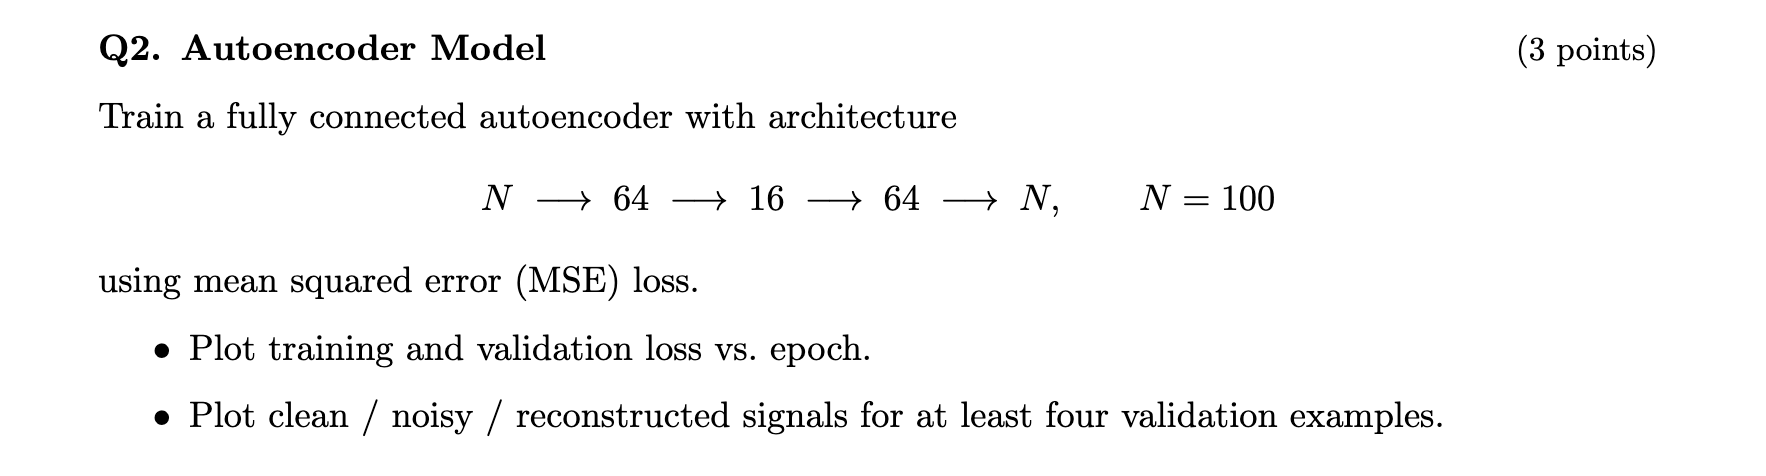

## Autoencoder Model

**Fully connected (dense) autoencoder**
- **Encoder** compresses the input into a low-dimensional **latent space**
- **Decoder** reconstructs the signal from the latent representation

The network is trained to minimise **mean squared error (MSE)** between the reconstructed and clean signal.

In [ ]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(16, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

## Training with .fit()

.fit() trains the model. The key arguments are:

| Argument | What it means |
|---|---|
| X_train, Y_train | The data the model learns from |
| epochs | How many times the model sees the full training data |
| batch_size | How many samples to process before updating the weights |
| validation_data=(X_val, Y_val) | Data the model never trains on. It is used to check performance after each epoch |
| verbose=1 | Shows a progress bar while training; set to 0 to hide it |

After training, history stores the training loss and validation loss at every epoch:

If validation loss starts increasing while training loss keeps decreasing -> the model is **overfitting** (memorising the training data instead of generalising).

In [ ]:
history = autoencoder.fit(
    X_train, Y_train,
    epochs=50,
    batch_size=128,
    validation_data=(X_val, Y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Plot the training and validation loss curves.

In [ ]:
# plot loss curves

## Making Predictions with .predict()

model.predict(X) passes the input array through the trained network and returns reconstructed outputs.

In [ ]:
examples = [0, 1, 2, 3]

reconstructed_Y = autoencoder.predict(X_val[examples]) # Returns shape (4, 100)

Plot the clean signal, noisy input, and reconstructed signal.

In [ ]:
# Plot clean / noisy / reconstructed for each example

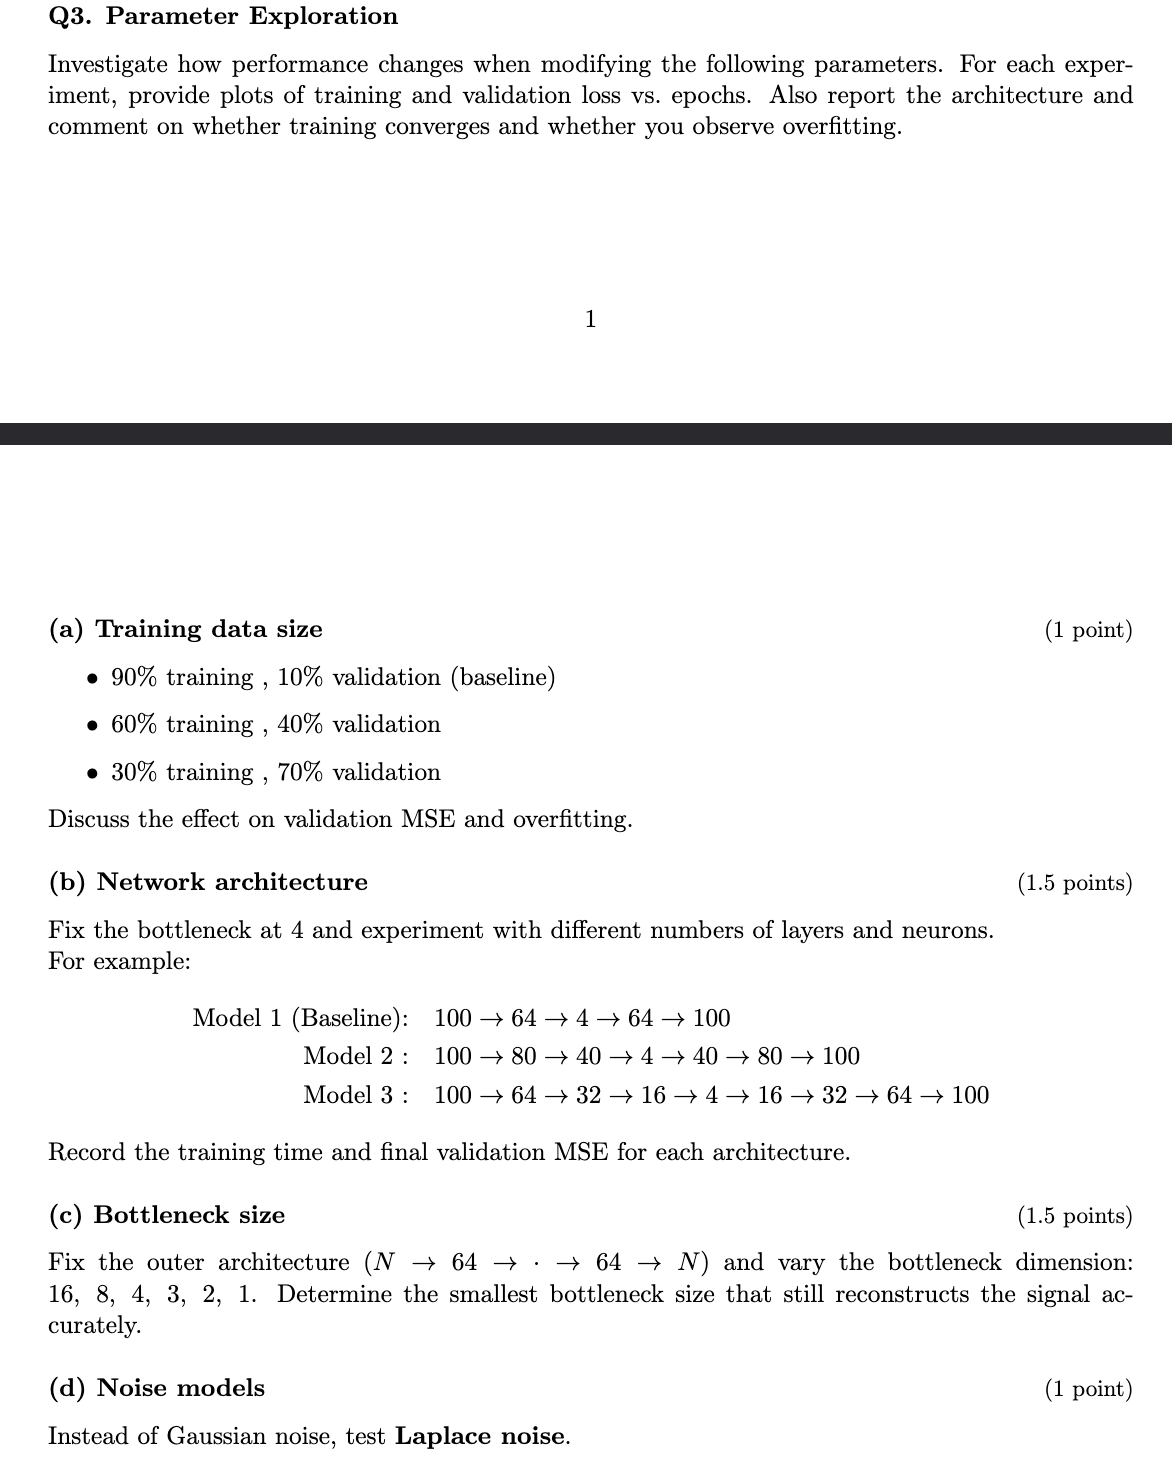